In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.signal import butter, filtfilt
import emd
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import gc
import os

# EMD CYCLE FEATURE EXTRACTION

In [2]:
def butter_bandpass_filter(data, lowcut=0.5, highcut=30.0, fs=200, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=0)

def get_emd_cycle_features(imfs, sample_rate=200, target_imfs=3):
    """
    Extracts Instantaneous Frequency (IF) and Amplitude (IA) stats 
    from the EMD cycles.
    """
    # Initialize empty features [Mean IF, Std IF, Mean IA, Std IA] per target IMF
    # Shape: (target_imfs * 4,)
    cycle_feats = np.zeros(target_imfs * 4)
    
    # If EMD failed and returned a 1D flatline instead of 2D IMFs
    if imfs.ndim == 1 or imfs.shape[1] == 0:
        return cycle_feats
        
    try:
        # Calculate Instantaneous Phase, Frequency, and Amplitude using Hilbert Transform
        IP, IF, IA = emd.spectra.frequency_transform(imfs, sample_rate, 'hilbert')
        
        # We only look at the first `target_imfs` (usually the most active high/mid frequencies)
        num_imfs_to_process = min(target_imfs, imfs.shape[1])
        
        for j in range(num_imfs_to_process):
            base_idx = j * 4
            # Mean and Std of Instantaneous Frequency for this IMF cycle
            cycle_feats[base_idx] = np.nanmean(IF[:, j])
            cycle_feats[base_idx + 1] = np.nanstd(IF[:, j])
            
            # Mean and Std of Instantaneous Amplitude for this IMF cycle
            cycle_feats[base_idx + 2] = np.nanmean(IA[:, j])
            cycle_feats[base_idx + 3] = np.nanstd(IA[:, j])
            
    except Exception as e:
        # Failsafe for mathematical errors in Hilbert transform on bad signals
        pass
        
    # Replace any potential NaNs generated during transforms with 0
    return np.nan_to_num(cycle_feats)

def process_emd_cycles(filtered_data):
    num_samples, num_channels = filtered_data.shape
    
    # target_imfs=3 * 4 features per IMF = 12 features per channel
    feats_per_channel = 12 
    all_channel_feats = np.zeros((num_channels, feats_per_channel))
    
    for i in range(num_channels):
        channel_signal = filtered_data[:, i]
        
        # SAFETY CHECK: Bypass EMD if signal is completely flat
        if np.var(channel_signal) < 1e-8:
            pass # Leaves zeros for this channel
        else:
            try:
                # Limit IMFs to 4 to drastically speed up processing
                imfs = emd.sift.sift(channel_signal, max_imfs=4)
                
                # Extract the cycle properties directly from the IMFs
                channel_features = get_emd_cycle_features(imfs, sample_rate=200, target_imfs=3)
                all_channel_feats[i, :] = channel_features
                
            except UnboundLocalError:
                pass
            except Exception:
                pass
                
    return all_channel_feats.flatten()


# DATASET PROCESSING LOOP

In [3]:

print("Loading data and extracting EMD Cycle Features...")

data_dir = '/Volumes/PortableSSD/code/practice_hms/classified_eeg_data'

# Map each file to a specific integer class label
target_mapping = {
    'eeg_trials_Seizure.npy': 0,
    'eeg_trials_LPD.npy': 1,
    'eeg_trials_GPD.npy': 2,
    'eeg_trials_LRDA.npy': 3,
    'eeg_trials_GRDA.npy': 4,
    'eeg_trials_Other.npy': 5
}

X_list = []
y_list = []

Loading data and extracting EMD Cycle Features...


In [ ]:
for filename, label in target_mapping.items():
    filepath = os.path.join(data_dir, filename)
    
    if not os.path.exists(filepath):
        print(f"Skipping {filename} - File not found.")
        continue
        
    print(f"Processing {filename}...")
    
    # Load the specific class file 
    # Assumption: The .npy file contains an array of shape (num_trials, num_samples, num_channels)
    class_data = np.load(filepath)
    
# Inside your processing loop:
    # Optional: class_data[:500] to test a small batch first
    for trial in tqdm(class_data): 
        
        # 1. Transpose the trial from (Channels, Time) to (Time, Channels)
        # Shape goes from (20, 10000) -> (10000, 20)
        trial_t = trial.T
        
        # 2. Crop to the middle 10 seconds to save massive EMD compute time
        # 10 seconds at 200Hz = 2000 samples
        trial_cropped = trial_t#[4000:6000, :]
        
        # 3. Bandpass Filter (now correctly filtering 2000 time steps)
        filtered_signal = butter_bandpass_filter(trial_cropped)
        
        # 4. Apply EMD & Extract Cycle Features
        features = process_emd_cycles(filtered_signal)
        
        # 5. Store features and the integer label
        X_list.append(features)
        y_list.append(label)
        
    del class_data
    gc.collect()

Processing eeg_trials_Seizure.npy...


# TRAIN THE XGBOOST MODEL

In [2]:
X = np.load('/Volumes/PortableSSD/code/practice_hms/X_emd_features.npy')
y = np.load('/Volumes/PortableSSD/code/practice_hms/y_emd_labels.npy')
print(f"Loaded successfully! X: {X.shape}, y: {y.shape}")

Loaded successfully! X: (109800, 240), y: (109800,)


In [ ]:
from sklearn.model_selection import train_test_split
import xgboost as xgb


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"訓練集 (Train): {X_train.shape}")
print(f"驗證集 (Validation): {X_val.shape}")
print(f"測試集 (Test): {X_test.shape}")

model = xgb.XGBClassifier(
    objective='multi:softprob', 
    num_class=6,               # 6 distinct EEG classifications
    n_estimators=5000, 
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mlogloss'     # Logloss is the standard for multi-class classification
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)], 
    verbose=10                  
)


from sklearn.metrics import log_loss, accuracy_score

y_test_pred_proba = model.predict_proba(X_test)
final_test_loss = log_loss(y_test, y_test_pred_proba)
print(f"最終未見資料的測試集表現 (Test mlogloss): {final_test_loss}")

訓練集 (Train): (70272, 240)
驗證集 (Validation): (17568, 240)
測試集 (Test): (21960, 240)
[0]	validation_0-mlogloss:1.78193	validation_1-mlogloss:1.78265
[10]	validation_0-mlogloss:1.69260	validation_1-mlogloss:1.69969
[20]	validation_0-mlogloss:1.61539	validation_1-mlogloss:1.62846
[30]	validation_0-mlogloss:1.54736	validation_1-mlogloss:1.56559
[40]	validation_0-mlogloss:1.48620	validation_1-mlogloss:1.50922
[50]	validation_0-mlogloss:1.43127	validation_1-mlogloss:1.45875
[60]	validation_0-mlogloss:1.38131	validation_1-mlogloss:1.41299
[70]	validation_0-mlogloss:1.33582	validation_1-mlogloss:1.37127
[80]	validation_0-mlogloss:1.29446	validation_1-mlogloss:1.33340
[90]	validation_0-mlogloss:1.25591	validation_1-mlogloss:1.29806
[100]	validation_0-mlogloss:1.21979	validation_1-mlogloss:1.26510
[110]	validation_0-mlogloss:1.18606	validation_1-mlogloss:1.23442
[120]	validation_0-mlogloss:1.15512	validation_1-mlogloss:1.20633
[130]	validation_0-mlogloss:1.12570	validation_1-mlogloss:1.17974
[140]

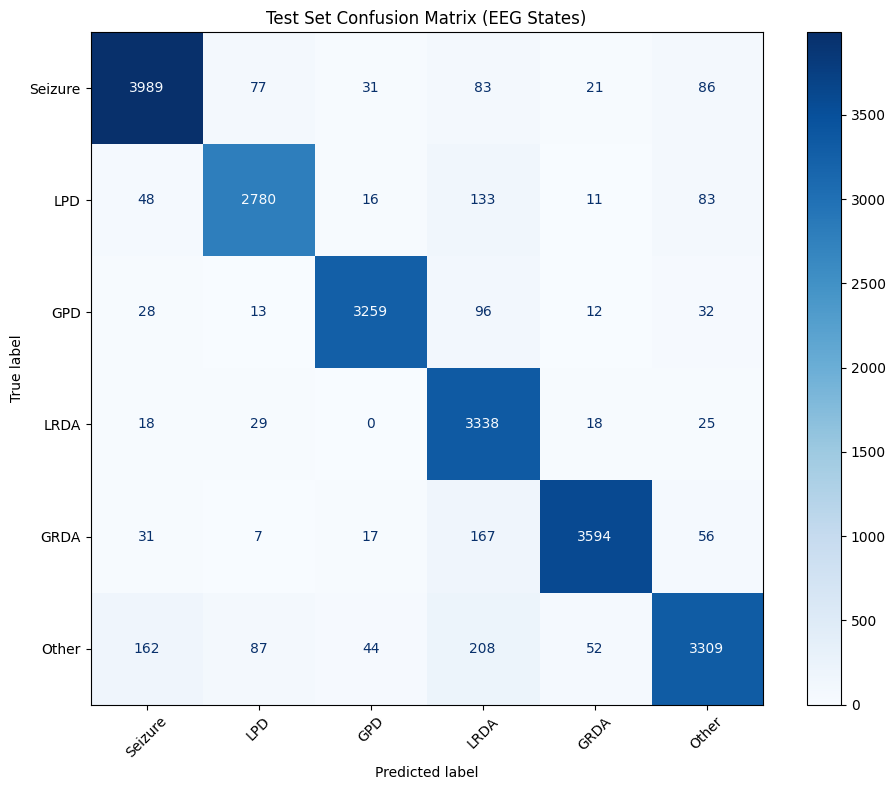


Classification Report:

              precision    recall  f1-score   support

     Seizure       0.93      0.93      0.93      4287
         LPD       0.93      0.91      0.92      3071
         GPD       0.97      0.95      0.96      3440
        LRDA       0.83      0.97      0.90      3428
        GRDA       0.97      0.93      0.95      3872
       Other       0.92      0.86      0.89      3862

    accuracy                           0.92     21960
   macro avg       0.92      0.92      0.92     21960
weighted avg       0.93      0.92      0.92     21960



In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

class_names = ['Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA', 'Other']

y_test_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)


fig, ax = plt.subplots(figsize=(10, 8)) # 稍微把圖放大一點，確保標籤放得下
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=class_names # 這裡直接帶入你的實際標籤
)


disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', xticks_rotation=45)

plt.title('Test Set Confusion Matrix (EEG States)')
plt.tight_layout() 
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, target_names=class_names))



In [ ]:

#model.save_model('/Volumes/PortableSSD/code/Seizure_app/eeg_xgb_model.ubj')
#print("Model saved to eeg_xgb_model.json")

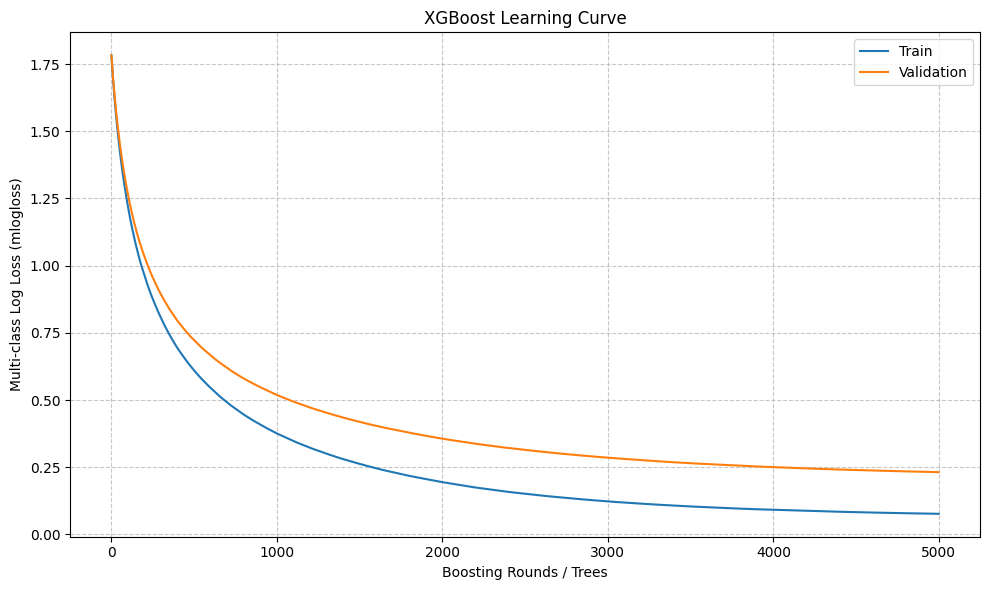

In [7]:
import matplotlib.pyplot as plt

# Retrieve performance metrics during training
results = model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

# Plot Log Loss
plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train')
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Validation')
plt.legend()
plt.ylabel('Multi-class Log Loss (mlogloss)')
plt.xlabel('Boosting Rounds / Trees')
plt.title('XGBoost Learning Curve')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

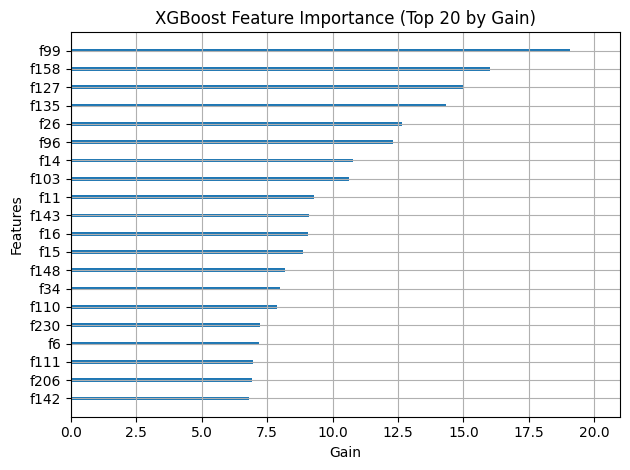

In [8]:
# Plot the top 20 most important features based on "gain"
# Gain implies the relative contribution of the corresponding feature to the model
plt.figure(figsize=(10, 8))
xgb.plot_importance(
    model, 
    max_num_features=20, 
    importance_type='gain', 
    show_values=False,
    title='XGBoost Feature Importance (Top 20 by Gain)',
    xlabel='Gain'
)
plt.tight_layout()
plt.show()

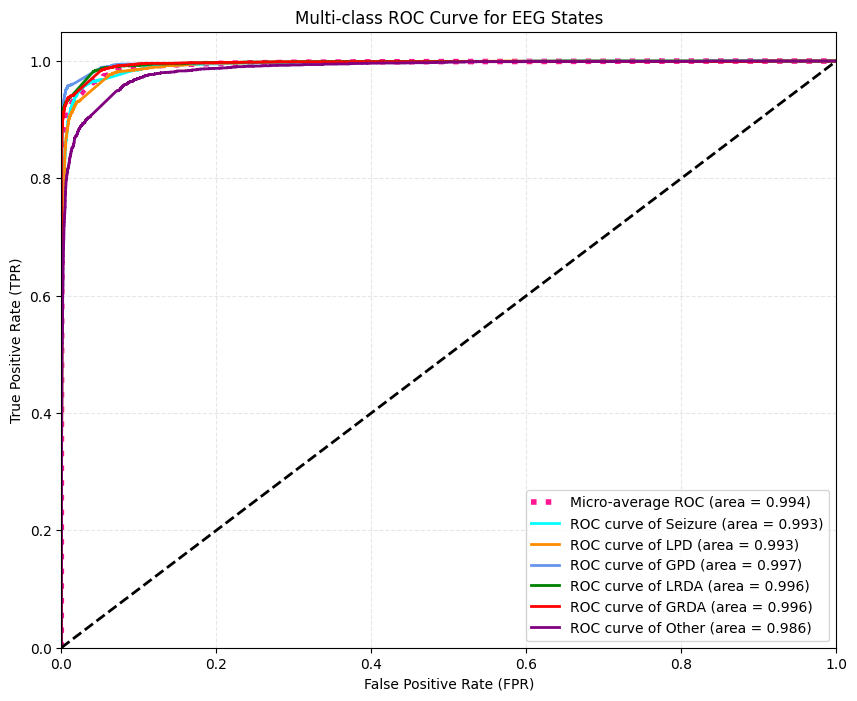

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np


class_names = ['Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA', 'Other']
n_classes = len(class_names)


y_test_bin = label_binarize(y_test, classes=range(n_classes))


fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_test_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


plt.figure(figsize=(10, 8))

plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC (area = {roc_auc["micro"]:0.3f})',
         color='deeppink', linestyle=':', linewidth=4)

colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:0.3f})') # 修改了這行的標籤


plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Multi-class ROC Curve for EEG States') 
plt.legend(loc="lower right")
plt.grid(alpha=0.3, linestyle='--')
plt.show()